# Lab 3: Exploring the Hodgkin Huxley model

Lab instructions: 
 - https://github.com/engmaths/SEMT30003_2025/blob/main/Labs/lab3/Lab3_Hodgkin_Huxley.pdf

Starter code:
 - https://github.com/engmaths/SEMT30003_2025/blob/main/Labs/lab3/hhhelper.py


#### Preliminaries

This notebook provides more explicit guidance for completing *Lab 3: Exploring the Hodgkin Huxley model*. The basic 

1. Study the example code in `hhhelper.py`, and use or copy this (or use AI to translate it into Julia/Matlab/R, if you chose to use a different language) to get started exploring the Hodgkin Huxley model as an ODE.
2. Create a new interactive iPython notebook (or equivalent in your language of choice), and start writing code to combine `hhhelper.py` with a built-in ODE solver. 
3. The above will probably entail Googling for documentation on how to use e.g. `scipy.integrate.solve_ivp` to simulate this system.  Bristol SEMT and CS students should already be well-familiar with looking up API documentation for writing code. Students joining us from other backgrounds can close this gap by asking the demonstrators for tutoring, or using an AI coding assitant like Claude/Copilot/Gemini to explain to them how to apply the function. (But please note that submitting AI generated code for the assessed extended coursework will not be permitted.)

The goal is to hit the following learning outcomes: 

1. Students should realize that if they have a is just an Ordinary Differential Equation (ODE, no jumps or stochasticity to confuse a basic IVP solver), it's easy to explore it using built-in tools. These are easier than writing your own loop and let you use more complicated methods that are fast and accurate. **You will want to use this in parts of your extended coursework submission.**
2. With some exploration, students learn about the Hodgkin Huxley model **(which is on the exam and assessed coursework)**, such as: 
    - How changes in the $(m,n,h)$ gating variables relate to changes in currents and voltage at various action potential stages
    - The role of voltage-gated potassium in quickly repolarizing the cell
    - The potentially for a voltage-gated potassium channel that closes slowly to cause a longer relative refractory period


# How to use this notebook

This notebook will walk you through solving Lab 3 a bit more explicitly, for those students who struggled to find a toehold in lab today.
Read the steps in each section, and fill in the missing code. 

The steps here are *suggestions*. The original conception of the lab left room for student initiative, creativity, to implement and explore solutions with whatever workflow they found most intuitive. So, please feel free to deviate or improve upon the steps here, provided you aim for the above learning outcomes. 

## 1: Prepare your workspace

1. Make a new directory named `20251010_my_lab3_HH_solution`, or something similar of your choice. In data science for life science, researchers are expected to keep a digital lab notebook that records their explorations and discoveries on each day or programming session. I tend to prefer `YYYYMMDD` date stamps for these entries, because it ensures that date stamps can't be lost or modified by file system operations, and turns an alphabetical ("lexical") sort into a "sort by creation date". You may, of course, set things up as you would like.

2. Grab `hhhelper.py` and `Lab3_Hodgkin_Huxley.pdf` from the course github and place them in the working directory you created in step (1)

3. We'll use an interactive notebook for our solutions today, so we can save a nice record of our results. Open up your Jupyterl lab notebook server, VSCode, or other notebook solution of your choice, and change to the directory you created in step 1.

4. If you're using python, you make a copy of this notebook `lab3_HH_exploration_scaffold.ipynb`, perhaps named something like `20251010_my_lab3_HH_exploration_scaffold_v1.ipynb`, in your working directory. If you've opened this notebook somewhere else, close it, and open your new working copy to work within that. If you're using some other programming environment, create whatever notebook or file you're going to use to store your solutions.

5. Keep the lab instructions `Lab3_Hodgkin_Huxley.pdf` open somewhere so you can reference them.

The rest of this notebook will assume that you are editing your own working copy, from within a directory that contains the `hhhelper.py`.

## 2: Import the code that you will use

The instructions say that we'll be using some helper code in `hhhelper.py` to integrate the HH model using `scipy.integrate.solve_ivp`.
Let's get things set up for that. 

1. Import generally useful tools. I used `from pylab import *`, which gives a Matlab-like namespace. 

2. Import the helper code from `hhhelper.py`

3. Import the `solve_ivp` function the instructions tell us to use.

In [1]:
from pylab           import *  # Create Matlab-like namespace
from hhhelper        import *  # Get the helper code
from scipy.integrate import solve_ivp # Integrates ODEs forward given an initial value
from seaborn         import despine   # Tidy axis

## 3.1a: Learn how `solve_ivp` works 

1. Open up a web browser, search for the documentation for `scipy.integrate.solve_ivp`, and keep that open in a browser tab. 
Or, ask AI to give you a quick usage example.
2. If you want to test things out, pick a really simply ODE like $\dot y = -1$, and check that you can use `solve_ivp` to get what you'd expect.
3. (done for your below) Complete a test cell to check that you understand how to use `solve_ivp`

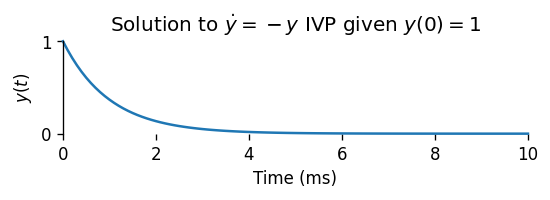

In [2]:
def ode(t,y):
    dydt = -y
    return dydt

start_time = 0  # ms
stop_time  = 10 # ms
plot_times = linspace(start_time,stop_time,stop_time*10+1)

y0= 1.
y = solve_ivp(
    ode,
    (start_time,stop_time),
    [y0],
    method="RK45",
    t_eval=plot_times).y[0]

figure(0,(5,1),120)
plot(plot_times, y, clip_on=False)
yticks([0,1]); 
ylim(0,y0); xlim(start_time, stop_time); 
xlabel("Time (ms)"); ylabel("$y(t)$")
title(r"Solution to $\dot y=-y$ IVP given $y(0)=1$")
despine(bottom=True) # from seaborn

## 3.1b (More succinct)

In §3.1a, we were quite verbose about how to use `solve_ivp`. I find it helpful to condense code into something a bit closer to mathematics, once I understand how it works. 

1. (done for you below) Redo 3.1a in a more compact way, moving boring code into helper functions. This is closer to what my own "test that I understand this" cell would look like in real life. 

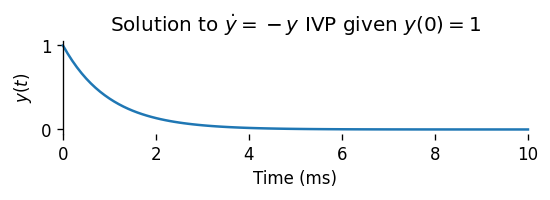

In [3]:
# Plot helper the student cobbled from Google / stack exchange
def quickaxis(xl="",yl="",mytitle=""):
    xlabel(xl)
    ylabel(yl)
    title(mytitle)
    autoscale(enable=True, axis='x', tight=True)
    despine(bottom=True)

T   = 10 # ms
tt  = linspace(0,T,T*10+1)
ode = lambda t,y:-y
y0  = 1.
y   = solve_ivp(ode,(0,T),[y0],"RK45",tt).y[0]

figure(0,(5,1),120); 
plot(plot_times, y, clip_on=False); 
yticks([0,1]); 
quickaxis(
    "Time (ms)",
    "$y(t)$",
    r"Solution to $\dot y=-y$ IVP given $y(0)=1$")

## 3.2: Understand the `hhhelper.py` code

The design pattern used in `hhhelper.py` is slightly unusual. It defines module functions `currents(v,m,n,h)` and `ode(v,m,n,h,I)` within its constructor. You can treat these as you would methods declared in the class body. Defining them here let's use keep the source code close to the mathematical notation, without having to litter expressions with `this.`. 

1. (done for you below) Complete a quick check that you understand what `hhhelper.py` provides. 

In [4]:
HH = HH_model() # instructions say this should work. 

# The instructions say that `currents(v,m,n,h)` and `ode(v,m,n,h,I)` exist
# Let's check? 

# Voltage in mV
v = -70 
# Set gating variables to anything in 0..1 to test
m,n,h = .1,.2,.3
# Applied current in nA
I = .1

# These should be the time derivatives
print("ODE time derivatives?",HH.ode(v,m,n,h,I))

# These should be the currents across the membrane
print("Currents?",HH.currents(v,m,n,h))

ODE time derivatives? [ 2.8955    -0.3232733 -0.0379614  0.0293192]
Currents? [ 1.5    -0.392   1.6875]


## 4: Begin working through the lab

At this point, we now understand two things:

1. `solve_ivp` wants a function that maps `(time,state)` to the model's derivatives, plus some instructions on the initial value and time range (and time points) that we want to obtain.
2. The `HH_model()` class seems to provide those derivatives for us (plus possibly something else we might use in the lab)


## Question 1

(done for you below) Read question 1 and convert it into code
1. Copy provided constants, set up the problem
2. Note that you're asked to write a wrapper to interface the provided model with `solve_ivp` (write it)
3. Solve the problem and get the result
4. Write code to plot what happened

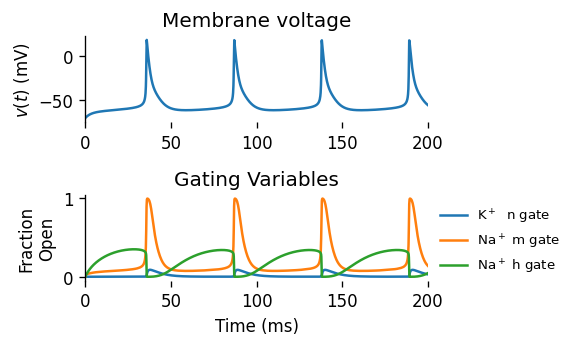

In [5]:
I = 0.7 # nA Applied current (indicated in Q1)
T = 200 # ms Simulation time (indicated in Q1)

# I noticed HH_model wants arguments in the order vmnh, so let's use that

# Time points (copy, paste from my test code above)
tt = linspace(0,T,T*10+1)

# The instructions say I need to write a wrapper?
# solve_ivp wants a function f:(t,state) → dstate/dt
# HH_model doesn't quite give us that, but I'll write a small wrapper?
def ode1(t,state):
    v,m,n,h = state
    return HH.ode(v,m,n,h,I)

# Initial conditions were"n't specified so perhaps they aren't too important?
# Just use something sensible (below)
v,m,n,h = solve_ivp(ode1,(0,T),[-70,0,0,0],"RK45",tt).y

figure(0,(5,3),120)
subplot(211); 
plot(tt,v); 
quickaxis("",'$v(t)$ (mV)',"Membrane voltage")
subplot(212); 
plot(tt,n,label='K$^+$  n gate')
plot(tt,m,label='Na$^+$ m gate')
plot(tt,h,label='Na$^+$ h gate')
quickaxis("Time (ms)",'Fraction\nOpen',"Gating Variables")
# below lines likely copy/pasted from Google/stackoverflow
legend(bbox_to_anchor=(1,1),fontsize=8,frameon=False)
tight_layout()

## Question 2

Steps
1. Copy/paste `model1.currents(v,m,n,h)` from the instructions
2. Note that it returns 3 things (what are they?) check source code to discover its `IL, IK, INa`
3. Make plotting code to your tastes

In [7]:
IL, IK, INa = HH.currents(v,m,n,h)

# Your code here

## Question 3

Example thought process:
 - I'm asked to check whether we really need voltage-gated potassium to repolarize this model. 
 - The prompt says to make a new model using `HH_model(gKmax=0)`, so I'll copy+past to start there
 - I'm not sure I want to rely on shadoing the original `HH` model object in the global workspace, so I'll make a new ODE wrapper `ode2` (this time more succinct, it's just some glue code)
 - Otherwise, looks like I can copy+paste the plotting code from Q1 to finish this.
 - Maybe I should go back and wrap the Q1 plotting code in a function so I don't have to keep pasting this? 
 - ...

In [ ]:
HHq3 = HH_model(gKmax=0)
v,m,n,h = solve_ivp(lambda t,vmnh:HHq3.ode(*vmnh,I),(0,T),[-70,0,0,0],"RK45",tt).y

# Your code here

## Question 4

Example thought process:
 - It looks like questions 4, 5 are similar to Question 3: Make a new model with different constants, explore and plot, and answer the prompted question.
 - Next steps up to you...

In [ ]:
# Your code here

## Question 5

Example thought process:
 - It looks like questions 4, 5 are similar to Question 3: Make a new model with different constants, explore and plot, and answer the prompted question.
 - Next steps up to you...

In [ ]:
# Your code here

# My answers

### Q1. 
(if plots worked, no response needed)

### Q2. 
**Do I see relatively little contribution from the potassium current?** 

(yes/no/maybe)

### Q3. 
**Without potassium, what mechanism is stopping the spike from rising, and what causes the neuron to return to rest after a spike?**

(write something here)

### Q4. 
**Comment on the role of voltage-gated potassium channels in the downswing of the action potential.**

(write something here)

### Q5. 
**Comment on the role of voltage-gated potassium channels in the relative refractory period.**

(write something here)